# Agente online de busca em profundiade

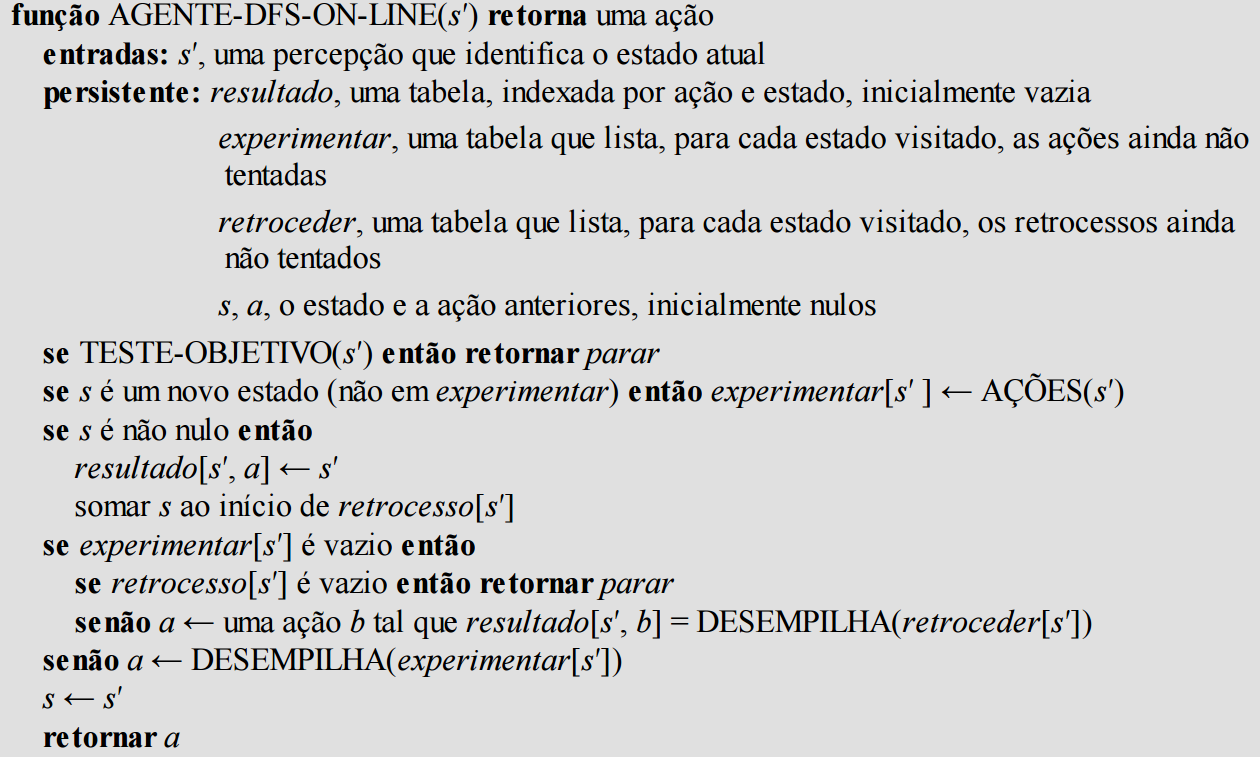

In [2]:
class AgenteDFSOnline:
    
    def __init__(self, acoes_func, teste_objetivo):
        """
        acoes_func: função que recebe um estado e retorna lista de ações possíveis
        teste_objetivo: função que recebe estado e retorna True/False
        """
        self.acoes_func = acoes_func
        self.teste_objetivo = teste_objetivo

        # Estruturas persistentes
        self.resultado = {}      # (s, a) -> s'
        self.experimentar = {}   # s -> lista de ações ainda não tentadas
        self.retroceder = {}     # s -> pilha de estados para voltar

        self.s = None  # estado anterior
        self.a = None  # ação anterior

    def agir(self, s_linha):
        # TESTE-OBJETIVO
        if self.teste_objetivo(s_linha):
            return None  # parar

        # Se estado novo
        if s_linha not in self.experimentar:
            self.experimentar[s_linha] = list(self.acoes_func(s_linha))
            self.retroceder[s_linha] = []

        # Se não é o primeiro passo
        if self.s is not None:
            self.resultado[(self.s, self.a)] = s_linha
            self.retroceder[s_linha].insert(0, self.s)

        # Se não há mais ações para explorar
        if not self.experimentar[s_linha]:
            if not self.retroceder[s_linha]:
                return None  # parar

            estado_volta = self.retroceder[s_linha].pop(0)

            # encontrar ação que leva de s' para estado_volta
            for (estado, acao), destino in self.resultado.items():
                if estado == s_linha and destino == estado_volta:
                    self.a = acao
                    break
        else:
            # pega próxima ação não testada
            self.a = self.experimentar[s_linha].pop(0)

        self.s = s_linha
        return self.a

In [4]:
# Grafo simples
grafo = {
    'A': ['B', 'C'],
    'B': ['A', 'D'],
    'C': ['A'],
    'D': []
}

def acoes(estado):
    return grafo[estado]

def objetivo(estado):
    return estado == 'D'

agente = AgenteDFSOnline(acoes, objetivo)

estado = 'A'

for i in range(10):
    acao = agente.agir(estado)
    
    if acao is None:
        print("Parou no estado:", estado)
        break

    print(f"Estado: {estado} -> Ação: {acao}")

    # simula movimento
    estado = acao

Estado: A -> Ação: B
Estado: B -> Ação: A
Estado: A -> Ação: C
Estado: C -> Ação: A
Estado: A -> Ação: C
Estado: C -> Ação: A
Estado: A -> Ação: C
Estado: C -> Ação: A
Estado: A -> Ação: C
Estado: C -> Ação: A
